**AMB2162_Pallavi P Bhat**

In [ ]:
CNN-

In [ ]:
import tensorflow as tf

# Step 1: Load dataset

mnist = tf.keras.datasets.mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
#( you can also give it as x_train,y_train)(x_test,y_test)


print("Train images shape:", train_images.shape)

# (60000, 28, 28)

print("Train labels shape:", train_labels.shape)

# (60000,)

print("Test images shape:", test_images.shape)
# (10000, 28, 28)

print("Test labels shape:", test_labels.shape)

# (10000,)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


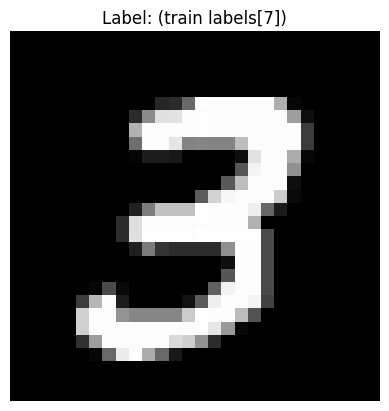

In [ ]:
import matplotlib.pyplot as plt

# Plot first image

plt.imshow(train_images[7], cmap='gray')
plt.title(f"Label: (train labels[7])")
# show the label
plt.axis('off')
plt.show()

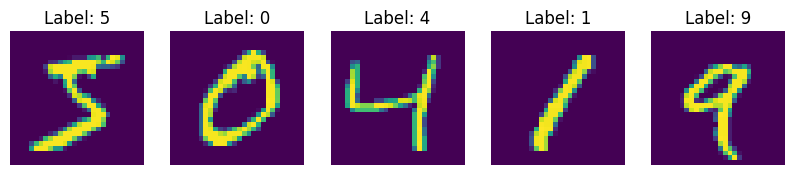

In [ ]:
plt.figure(figsize=(10,2))

for i in range(5):

 plt.subplot(1,5,i+1)

 plt.imshow(train_images[i])

 plt.title(f"Label: {train_labels[i]}")

 plt.axis('off')

plt.show()


In [ ]:
#step 2 : normalization
train_images=train_images/255.0
test_images=test_images/255.0

In [ ]:
#step 3 : add channel dimention (impotant) for cnn
train_images=train_images.reshape((60000,28,28,1))
test_images=test_images.reshape((10000,28,28,1))

In [ ]:
from tensorflow.keras import layers, models

model = models. Sequential([

layers.Conv2D(16, (3,3), activation ='relu', input_shape=(28,28,1)),

layers.MaxPooling2D(2,2),

layers.Flatten(),

layers.Dense (32, activation='relu'),

layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Step 5: Comp (function) optimizer: Any

model.compile(optimizer='adam',

             loss='sparse_categorical_crossentropy',

             metrics=['accuracy'])

#Step 6: Train model

model.fit(train_images, train_labels, epochs=3)


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9860 - loss: 0.0450
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - accuracy: 0.9894 - loss: 0.0340
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9916 - loss: 0.0278


In [ ]:
# step 7: test model
test_loss,test_acc=model.evaluate(test_images,test_labels)
print("accuracy :",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9817 - loss: 0.0599
accuracy : 0.9817000031471252


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Original Label: 0
Predicted Label: 0


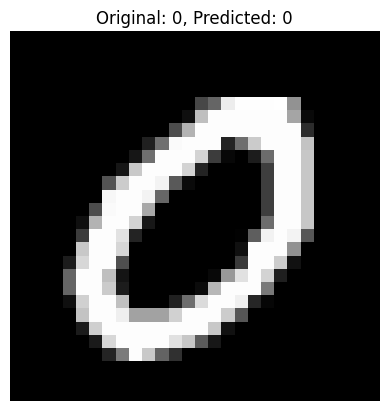

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Pick a random index
index = np.random.randint(0, len(test_images))

# Get image and label
sample_image = test_images[index]
true_label = test_labels[index]

# Expand dimensions for model input
sample_image_input = np.expand_dims(sample_image, axis=0)

# Predict
prediction = model.predict(sample_image_input) # gives probability from 0 to 9
predicted_label = np.argmax(prediction) # gives the index of highest probability

# Print results
print("Original Label:", true_label)
print("Predicted Label:", predicted_label)

# Show the image
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f"Original: {true_label}, Predicted: {predicted_label}")
plt.axis('off')
plt.show()


In [ ]:
# Step 4: Build CNN model

model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'), #convolution layer 2
    tf.keras.layers.MaxPooling2D(2,2), #pooling layer 2

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Step 5: Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Step 6: Train model
model.fit(train_images, train_labels, epochs=3)
#print(model.summary())

# Step 7: Test model
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Accuracy:", test_acc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9459 - loss: 0.1838
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9790 - loss: 0.0677
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9845 - loss: 0.0497
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9860 - loss: 0.0387
Accuracy: 0.9860000014305115
